<a href="https://colab.research.google.com/github/AlejoCNYT/AdA-Actividad-individual-2/blob/main/ACTIVIDAD_INDIVIDUAL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Descargar el dataset
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

# Configuración de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

# Cargar el CSV correctamente
df = pd.read_csv(path + "/heart.csv")
df.head()



Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.describe(include='object')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [ ]:
# Reemplazamos los ceros fisiológicamente imposibles por NaN
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

print("Nulos ahora en Cholesterol:", df['Cholesterol'].isnull().sum())
print("Nulos ahora en RestingBP:", df['RestingBP'].isnull().sum())

Nulos ahora en Cholesterol: 172
Nulos ahora en RestingBP: 1


> Se detectaron valores de *Cholesterol = 0* en 172 registros (~18.7% del dataset) y *RestingBP = 0* en 1 registro. Dado que ambos valores son fisiológicamente imposibles en una persona con vida, se interpretan como **datos faltantes codificados como cero**, probablemente producto de la unificación de múltiples bases de datos clínicas de origen (Cleveland, Hungría, Suiza, Long Beach VA y Stalog). No se realizan correcciones en esta etapa por tratarse de un análisis exploratorio (EDA); su tratamiento (imputación o eliminación) correspondería a una etapa posterior de preprocesamiento.


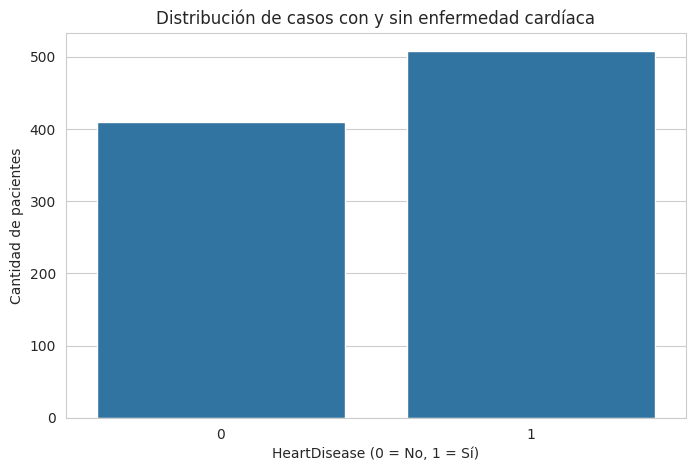

In [ ]:
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribución de casos con y sin enfermedad cardíaca')
plt.xlabel('HeartDisease (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de pacientes')
plt.show()

**Gráfico 1: Distribución de HeartDisease**

  Aproximadamente 410 pacientes sin enfermedad (0) y ~510 con enfermedad (1).
  Confirma lo que vimos en el describe() (media 0.55): el dataset está razonablemente balanceado, con una leve mayoría de casos positivos.
  No hay un desbalance grave de clases, lo cual es positivo de cara a un futuro modelo de clasificación.


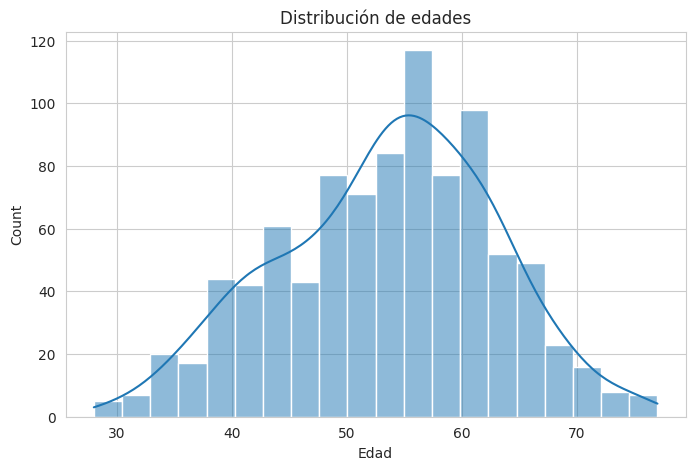

In [ ]:
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.show()

In [ ]:
df['Cholesterol'].skew()

np.float64(1.2385344368481757)

In [ ]:
df['Cholesterol'].kurt()

np.float64(4.528592419605934)

**Gráfico 2: Distribución de edades**

   Distribución con forma aproximadamente normal, levemente concentrada entre los 50 y 60 años, con la moda alrededor de los 55. Hay menos casos en los extremos (jóvenes de ~28-30 y adultos mayores de ~75-77). La población del estudio es predominantemente adulta y adulta mayor, coherente con el hecho de que el riesgo cardiovascular aumenta con la edad


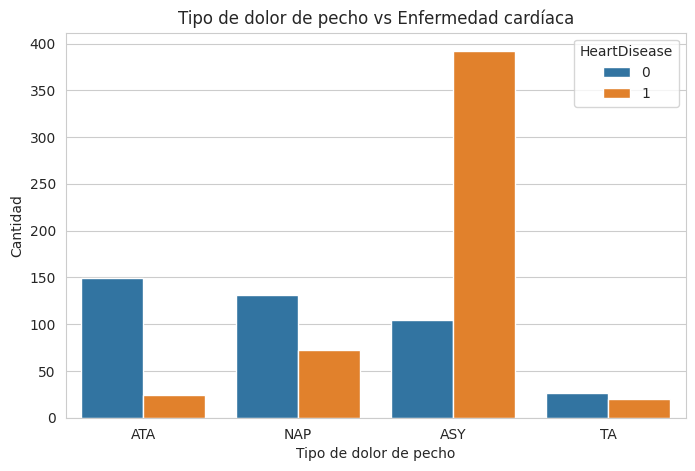

In [ ]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.title('Tipo de dolor de pecho vs Enfermedad cardíaca')
plt.xlabel('Tipo de dolor de pecho')
plt.ylabel('Cantidad')
plt.show()

**Gráfico 3: Tipo de dolor de pecho vs Enfermedad cardíaca (el más rico clínicamente)**

   ASY (asintomático): la gran mayoría de estos pacientes (~390 de ~495) SÍ tienen enfermedad cardíaca. Es el hallazgo más fuerte del gráfico.
   ATA, NAP, TA: en estos tres tipos (que sí presentan síntomas de dolor), la mayoría de los pacientes NO tienen enfermedad, o está más parejo.


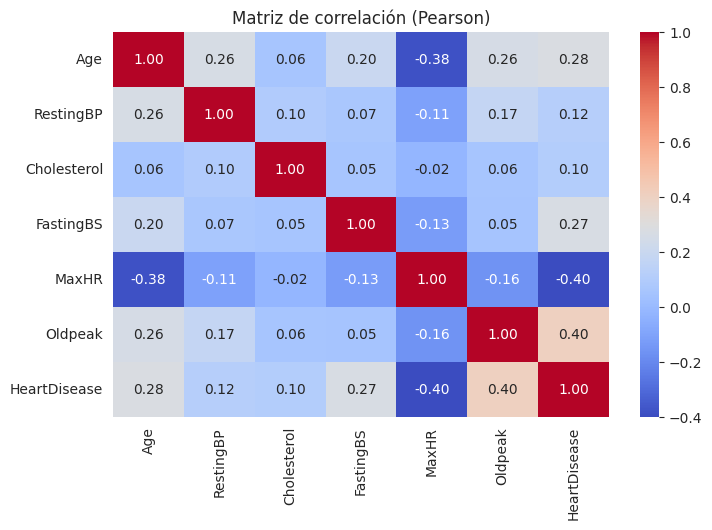

In [ ]:
corr = df.corr(numeric_only=True, method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación (Pearson)')
plt.show()

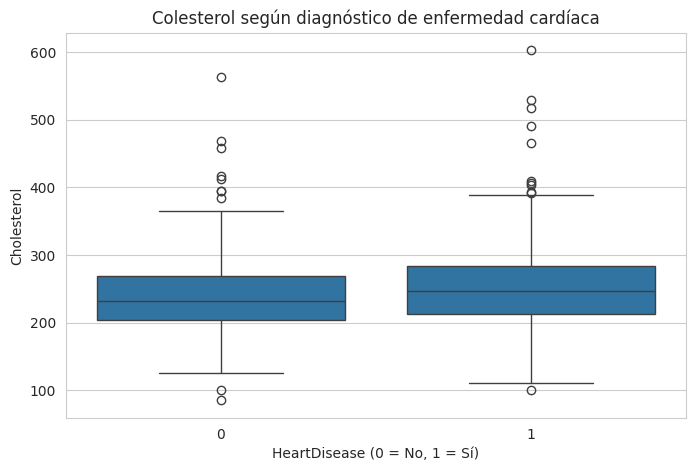

In [ ]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)
plt.title('Colesterol según diagnóstico de enfermedad cardíaca')
plt.xlabel('HeartDisease (0 = No, 1 = Sí)')
plt.ylabel('Cholesterol')
plt.show()

> **Conclusiones del EDA:**
>    * El dataset no presenta nulos explícitos, pero sí valores codificados como 0 en Cholesterol (18.7%) y RestingBP (0.1%) que representan datos faltantes disfrazados.
> * La variable objetivo (HeartDisease) está razonablemente balanceada (55.3% positivos).
> * La población está mayormente concentrada entre 45 y 65 años.
> * Existe un fuerte predominio de pacientes de sexo masculino (79%), lo que podría introducir sesgo en futuros modelos.
> * Se observa una relación clínicamente relevante entre el tipo de dolor de
    pecho y la enfermedad: los pacientes asintomáticos (ASY) presentan mayor proporción de enfermedad cardíaca, lo que sugiere que la ausencia de síntomas no implica ausencia de riesgo.
